In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [2]:
import os

# Show current working directory
print(os.getcwd())

# List all files in working directory folder
print(os.listdir())

C:\Users\anag_\OneDrive\Documentos\Python\BI_Portfolio\Python_DataAnalysis\Projects\superstore_sales
['.ipynb_checkpoints', 'Annual Profit by Segment.png', 'Boxplot by Category and Region.png', 'Boxplot by Region and Category.png', 'sales_by_sub-category.png', 'sales_by_sub-category2.png', 'superstore_data.csv', 'superstore_sales.ipynb']


In [3]:
#Load dataset
df = pd.read_csv('superstore_data.csv', encoding='latin1') #encoding to eliminate error 

In [4]:
#preview
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
#dataset description
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
#descriptive statistics
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
#drop missing values
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
#change format to "order date" column
df['Order Date'] = pd.to_datetime(df['Order Date'])

#add profit margin column
df['Profit Margin'] = df['Profit']/df['Sales']

In [9]:
#check new dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [10]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Profit Margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,0.120314
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,0.466754
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,-2.750000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,0.075000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,0.270000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,0.362500
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,0.500000


In [11]:
#group sales and profit by category
sales_category = df.groupby(['Category'])['Sales'].sum().sort_values(ascending=False)
profit_category = df.groupby(['Category'])['Profit'].sum().sort_values(ascending=False)
print(sales_category)

#reset index is used to generate plots
sales_category = sales_category.reset_index()
profit_category = profit_category.reset_index()
print(sales_category)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64
          Category        Sales
0       Technology  836154.0330
1        Furniture  741999.7953
2  Office Supplies  719047.0320


In [12]:
#group sales by category and sub-category
df_sales_cat_subcat = df.groupby(['Category','Sub-Category'])
df_profit_cat_subcat = df.groupby(['Category','Sub-Category'])

sales_category_subcat = df_sales_cat_subcat['Sales'].sum().sort_values(ascending=False)
profit_category_subcat = df_profit_cat_subcat['Profit'].sum().sort_values(ascending=False)

sales_category_subcat = sales_category_subcat.reset_index()
profit_category_subcat = profit_category_subcat.reset_index()

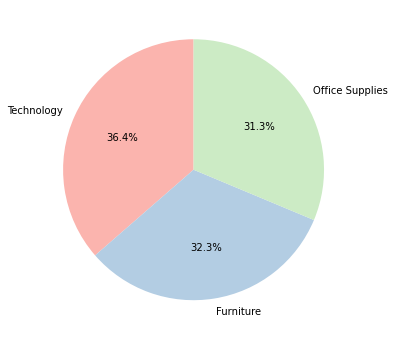

In [13]:
#Pie Chart using Matplotlib
plt.figure(figsize=(6,6))
plt.pie(sales_category['Sales'], 
        labels=sales_category['Category'],
        autopct='%1.1f%%',     # Muestra el porcentaje
        startangle=90,
        colors= plt.cm.Pastel1.colors)

plt.show()

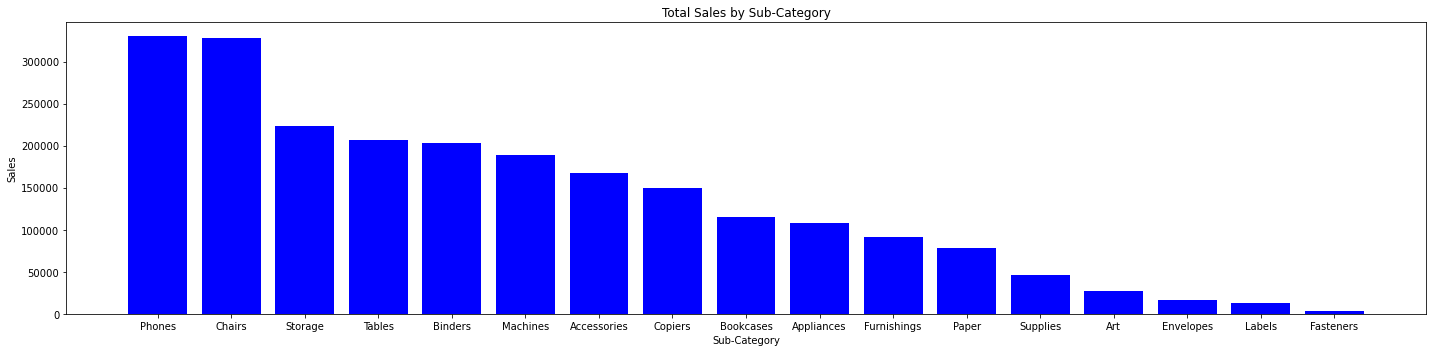

In [14]:
#Bar Graph using Matplotlib
plt.figure(figsize=(20,5))
plt.bar(sales_category_subcat['Sub-Category'], sales_category_subcat['Sales'], color='blue')
plt.title('Total Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('sales_by_sub-category.png')
plt.show()

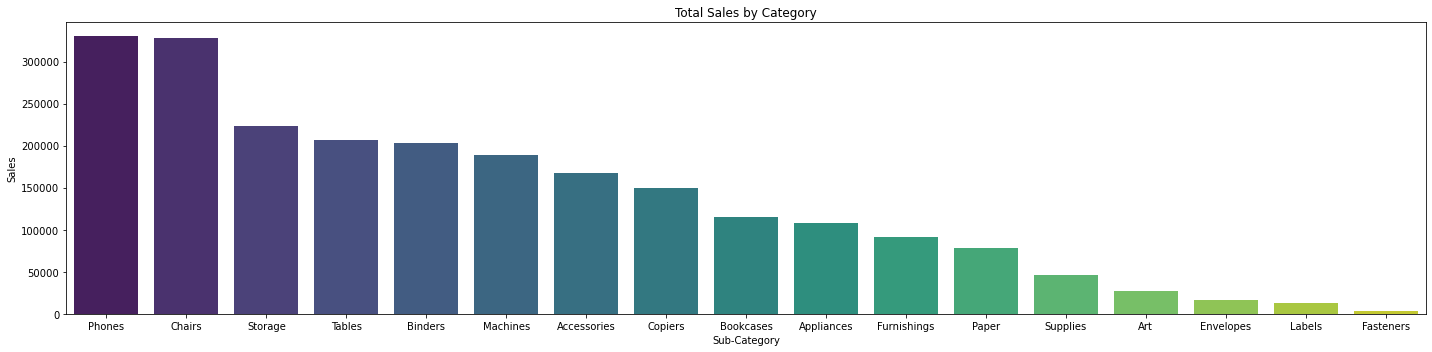

In [15]:
#Bar Graph using Seaborn
plt.figure(figsize=(20,5))
sns.barplot(data=sales_category_subcat, x='Sub-Category', y='Sales', palette='viridis')
plt.title('Total Sales by Category')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('sales_by_sub-category2')
plt.show()

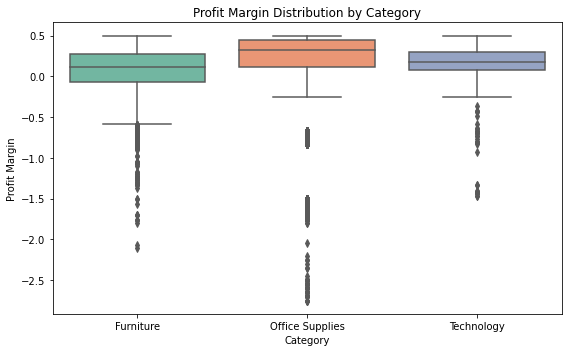

In [16]:
#Boxplot for Profits by category
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Category', y='Profit Margin', palette='Set2')
plt.title('Profit Margin Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Profit Margin')
plt.tight_layout()
plt.show()

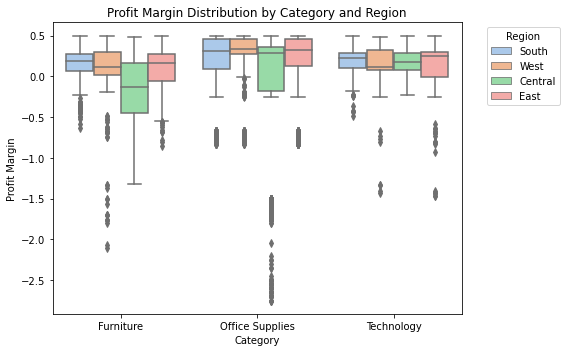

In [17]:
#Boxplot for Profits by category and region
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Category', y='Profit Margin', hue = 'Region', palette='pastel')
plt.title('Profit Margin Distribution by Category and Region')
plt.xlabel('Category')
plt.ylabel('Profit Margin')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Boxplot by Category and Region')
plt.show()

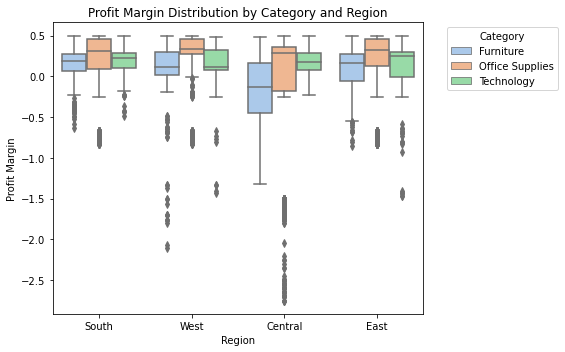

In [18]:
#Boxplot for Profits by category and region
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, hue='Category', y='Profit Margin', x='Region', palette='pastel')
plt.title('Profit Margin Distribution by Category and Region')
plt.xlabel('Region')
plt.ylabel('Profit Margin')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Boxplot by Region and Category')
plt.show()

In [19]:
#add aux columns
df_aux = df
df_aux['Year'] = df_aux['Order Date'].dt.year
df_aux['Month'] = df_aux['Order Date'].dt.month
df_aux['Day'] = df_aux['Order Date'].dt.day
df_aux.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Year,Month,Day
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.1600,2016,11,8
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.3000,2016,11,8
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.4700,2016,6,12
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.4000,2015,10,11
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.1125,2015,10,11


In [20]:
df_aux_segm = df_aux.groupby(['Year','Segment'])['Profit'].sum()
df_aux_segm = df_aux_segm.reset_index()
df_aux_segm

,Year,Segment,Profit
0,2014,Consumer,24319.8504
1,2014,Corporate,13513.2769
2,2014,Home Office,11710.8468
3,2015,Consumer,28460.1665
4,2015,Corporate,20688.3248
5,2015,Home Office,12470.1124
6,2016,Consumer,35770.9532
7,2016,Corporate,30995.1690
8,2016,Home Office,15029.0521
9,2017,Consumer,45568.2391


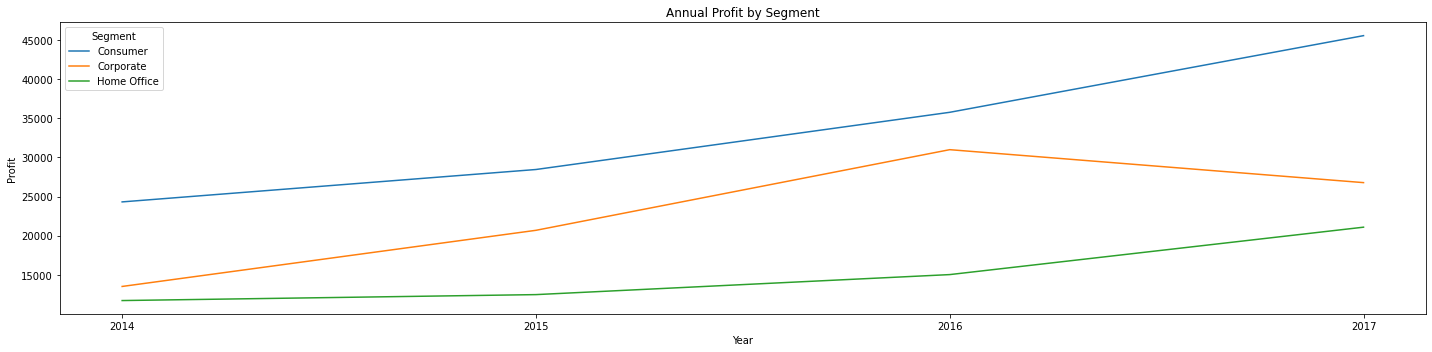

In [21]:
plt.figure(figsize=(20,5))
sns.lineplot(data=df_aux_segm, x='Year', hue='Segment', y='Profit')
plt.title('Annual Profit by Segment')
plt.xlabel('Year')
plt.ylabel('Profit')
plt.legend(title='Segment')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))  #ticks every 1 unit
plt.tight_layout()
plt.savefig('Annual Profit by Segment.png')
plt.show()